In [1]:
!pip install prophet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
import joblib

In [3]:
df = pd.read_csv("/content/Superstore dataset.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [8]:

sales_df = (
    df.groupby('Order Date')['Sales']
      .sum()
      .reset_index()
)

In [9]:
sales_df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [10]:
sales_df.columns = ['ds','y']

In [11]:
sales_df.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


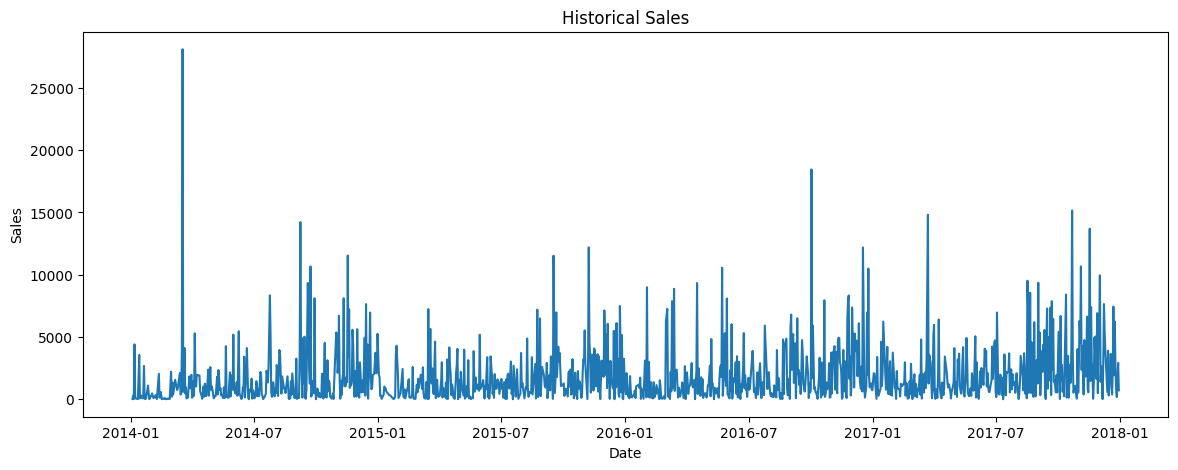

In [12]:
plt.figure(figsize=(14,5))

plt.plot(
    sales_df['ds'],
    sales_df['y']
)

plt.title("Historical Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [13]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(sales_df)

In [14]:
future = model.make_future_dataframe(
    periods=180
)

In [15]:
future.tail()

,ds
1412,2018-06-24
1413,2018-06-25
1414,2018-06-26
1415,2018-06-27
1416,2018-06-28


In [16]:
forecast = model.predict(future)

In [17]:
forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1407,2018-06-19,1909.816744,-830.761559,4663.493486
1408,2018-06-20,1031.530928,-1787.563630,3856.635137
1409,2018-06-21,2219.918135,-488.958636,5120.712022
1410,2018-06-22,2477.251056,-406.625992,5219.018827
1411,2018-06-23,2074.211590,-830.863425,4804.952308
1412,2018-06-24,2253.289697,-556.146723,5025.186710
1413,2018-06-25,2459.458551,-250.187782,4842.949359
1414,2018-06-26,1875.146476,-799.202705,4745.585329
1415,2018-06-27,1007.012827,-1695.525831,3673.245783
1416,2018-06-28,2204.463620,-556.525007,4872.738582


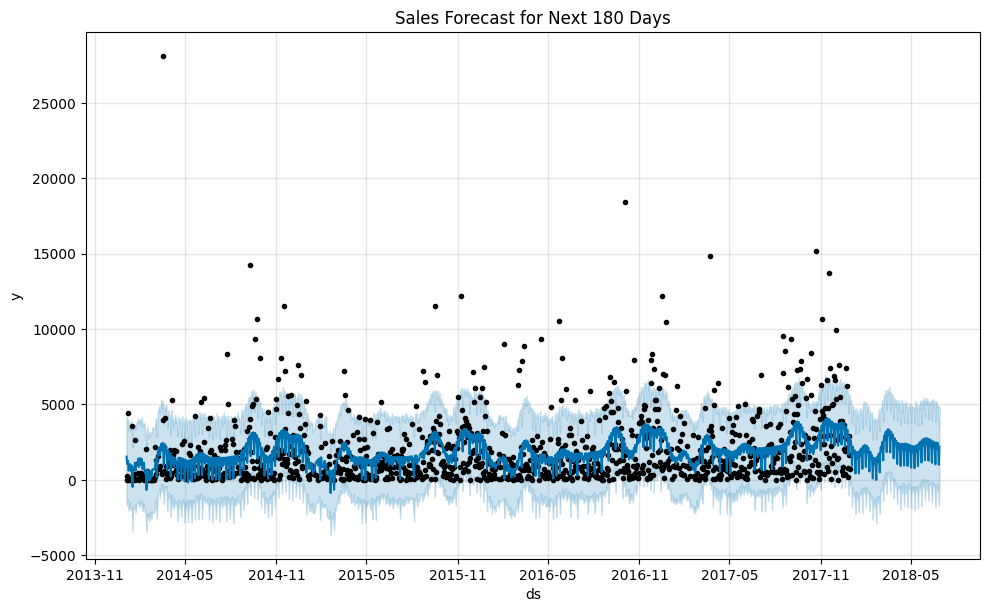

In [18]:
fig1 = model.plot(forecast)
plt.title("Sales Forecast for Next 180 Days")
plt.show()

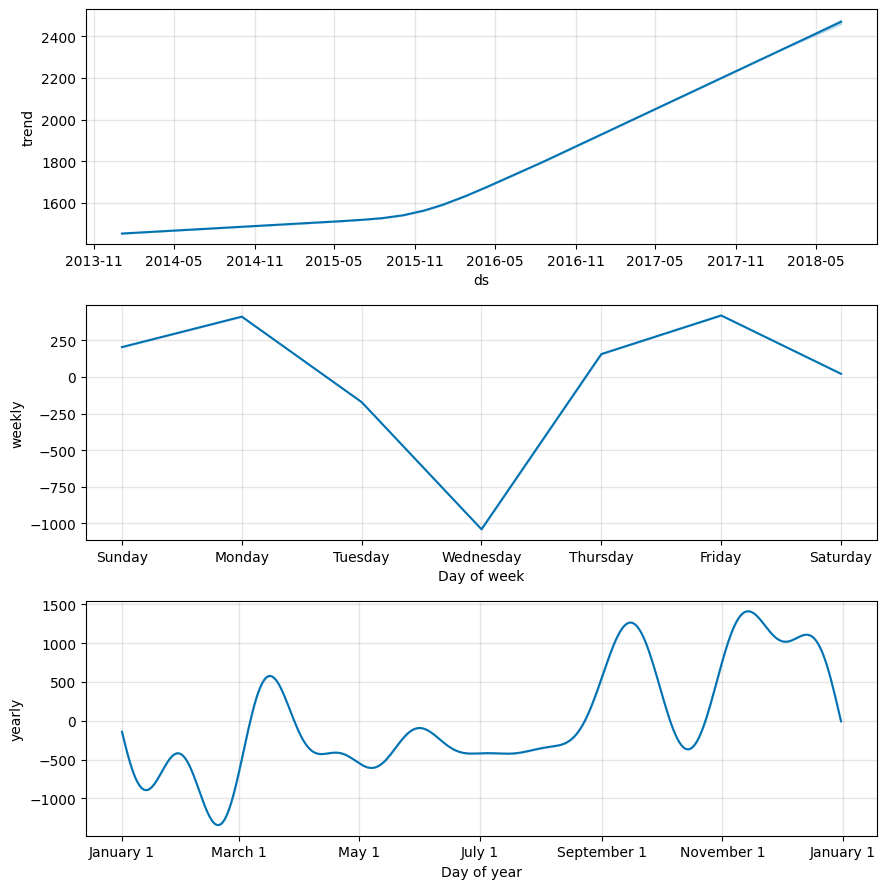

In [19]:
fig2 = model.plot_components(forecast)
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error

merged = sales_df.merge(
    forecast[['ds','yhat']],
    on='ds'
)

mae = mean_absolute_error(
    merged['y'],
    merged['yhat']
)

print("MAE:", round(mae,2))

MAE: 1402.97


In [21]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(
        merged['y'],
        merged['yhat']
    )
)

print("RMSE:", round(rmse,2))

RMSE: 2136.44


In [22]:
joblib.dump(
    model,
    "forecast_model.pkl"
)

['forecast_model.pkl']

In [23]:
from google.colab import files

files.download(
    "forecast_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
forecast.to_csv(
    "future_sales_forecast.csv",
    index=False
)

In [25]:
files.download(
    "future_sales_forecast.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>